# Modelos Multimodales
### Máster en IA y Computación Cuántica Aplicada a los Mercados Financieros (MIAX)

---

- **Autor:** Pablo Hernández Cámara
- **Contacto:** [pablo.hernandez-camara@uv.es](mailto:pablo.hernandez-camara@uv.es)
- **Notebook:** Fine-tuning a VLM

## 1. Dependencias

Empezamos instalando las librerías necesarias.

In [ ]:
!pip install -U -q git+https://github.com/huggingface/trl.git bitsandbytes peft qwen-vl-utils trackio transformers datasets accelerate torchao

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 2. Dataset 📁

Vamos a usar el [HuggingFaceM4/ChartQA](https://huggingface.co/datasets/HuggingFaceM4/ChartQA) dataset. Contiene imágenes de gráficos con sus correspondientes preguntas y respuestas. Es un dataset de VQA.

Primero vamos a generar el system prompt para el modelo. Vamos a decirle que es un experto en analizar gráficos y responder de forma concisa a las preguntas.

In [ ]:
system_message = """You are a Vision Language Model specialized in interpreting visual data from chart images.
Your task is to analyze the provided chart image and respond to queries with concise answers, usually a single word, number, or short phrase.
The charts include a variety of types (e.g., line charts, bar charts) and contain colors, labels, and text.
Focus on delivering accurate, succinct answers based on the visual information. Avoid additional explanation unless absolutely necessary."""

Formateamos el dataset con la estructura de chatbot estándar del modelo. Cada mensaje consiste en el system prompt seguido de la imagen y la pregunta, y finalmente la respuesta correcta.

Cada modelo puede tener una forma distinta de pasarle las preguntas; la de este en particular que vamos a usar se puede comprobar en su [Model Card](https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct#more-usage-tips).

In [ ]:
def format_data(sample):
    # El split de eval de ChartQA trae a veces "label" como lista en vez de string,
    # y eso rompe las cosas si acaban mezclándose ambos tipos. Nos quedamos siempre con un string.
    label = sample["label"][0] if isinstance(sample["label"], list) else sample["label"]

    messages = [{"role": "system", "content": [{"type": "text", "text": system_message}]},
                {"role": "user", "content": [{"type": "image"},
                                             {"type": "text", "text": sample["query"]}]},
                {"role": "assistant", "content": [{"type": "text", "text": str(label)}]}]

    return {"messages": messages, "images": [sample["image"]]}

Cargamos solo parte del dataset para que vaya más rápido.

In [ ]:
from datasets import load_dataset

dataset_id = "HuggingFaceM4/ChartQA"
train_dataset, eval_dataset, test_dataset = load_dataset(dataset_id, split=['train[:2%]', 'val[:2%]', 'test[:2%]'])

README.md:   0%|          | 0.00/852 [00:00<?, ?B/s]

data/train-00000-of-00003-49492f364babfa(…): reconstructing file:   0%|          |  0.00B /  219MB            

data/train-00000-of-00003-49492f364babfa(…): downloading bytes:           |  0.00B            

data/train-00001-of-00003-7302bae5e425bb(…): reconstructing file:   0%|          |  0.00B /  311MB            

data/train-00001-of-00003-7302bae5e425bb(…): downloading bytes:           |  0.00B            

...

data/test-00000-of-00001-e2cd0b7a0f9eb20(…): reconstructing file:   0%|          |  0.00B / 68.9MB            

data/test-00000-of-00001-e2cd0b7a0f9eb20(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/28299 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/1920 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2500 [00:00<?, ? examples/s]

Si vemos la estructura, lo que nos interesa es "image", "query" y "label".

In [ ]:
train_dataset

Dataset({
    features: ['image', 'query', 'label', 'human_or_machine'],
    num_rows: 1415
})

Formateamos con la estructura que hemos definido.

In [ ]:
# Usamos .map() para que el tipo Image de HuggingFace se mantenga intacto. Más adelante veremos por qué esto es importante.
train_dataset = train_dataset.map(format_data, remove_columns=train_dataset.column_names)
eval_dataset = eval_dataset.map(format_data, remove_columns=eval_dataset.column_names)
test_dataset = test_dataset.map(format_data, remove_columns=test_dataset.column_names)

Map:   0%|          | 0/1415 [00:00<?, ? examples/s]

Map:   0%|          | 0/96 [00:00<?, ? examples/s]

Map:   0%|          | 0/125 [00:00<?, ? examples/s]

In [ ]:
print(len(train_dataset))
print(len(eval_dataset))
print(len(test_dataset))

1415
96
125


Y vemos un ejemplo:

In [ ]:
train_dataset[200]

{'messages': [{'role': 'system',
   'content': [{'type': 'text',
     'text': 'You are a Vision Language Model specialized in interpreting visual data from chart images.\nYour task is to analyze the provided chart image and respond to queries with concise answers, usually a single word, number, or short phrase.\nThe charts include a variety of types (e.g., line charts, bar charts) and contain colors, labels, and text.\nFocus on delivering accurate, succinct answers based on the visual information. Avoid additional explanation unless absolutely necessary.'}]},
  {'role': 'user',
   'content': [{'type': 'image'},
    {'type': 'text',
     'text': 'Is the rightmost value of light brown graph 58?'}]},
  {'role': 'assistant', 'content': [{'type': 'text', 'text': 'No'}]}],
 'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGB size=308x369>]}

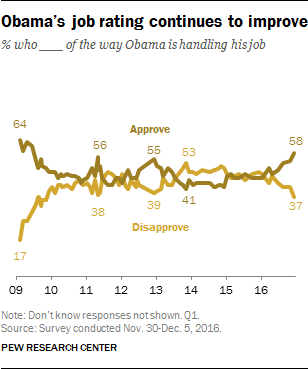

In [ ]:
train_dataset[200]['images'][0]

## 3. Modelo

Vamos a usar [Qwen/Qwen2-VL-2B-Instruct](https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct), un Vision Language Model (VLM).

In [ ]:
import torch
from transformers import Qwen2VLForConditionalGeneration, Qwen2VLProcessor

model_id = "Qwen/Qwen2-VL-2B-Instruct"

model = Qwen2VLForConditionalGeneration.from_pretrained(model_id,
                                                        device_map="auto",
                                                        torch_dtype=torch.bfloat16,)

processor = Qwen2VLProcessor.from_pretrained(model_id)

config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/56.4k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

...

preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Vamos a ver cómo va en el dataset; para probar cogemos solo una pregunta.

In [ ]:
train_dataset[0]

{'messages': [{'role': 'system',
   'content': [{'type': 'text',
     'text': 'You are a Vision Language Model specialized in interpreting visual data from chart images.\nYour task is to analyze the provided chart image and respond to queries with concise answers, usually a single word, number, or short phrase.\nThe charts include a variety of types (e.g., line charts, bar charts) and contain colors, labels, and text.\nFocus on delivering accurate, succinct answers based on the visual information. Avoid additional explanation unless absolutely necessary.'}]},
  {'role': 'user',
   'content': [{'type': 'image'},
    {'type': 'text', 'text': 'Is the value of Favorable 38 in 2015?'}]},
  {'role': 'assistant', 'content': [{'type': 'text', 'text': 'Yes'}]}],
 'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGB size=422x359>]}

Se la pasaremos sin el system prompt que hemos definido, para evaluar el modelo tal cual (zero-shot).

In [ ]:
train_dataset[0]['messages'][1:2]

[{'role': 'user',
  'content': [{'type': 'image'},
   {'type': 'text', 'text': 'Is the value of Favorable 38 in 2015?'}]}]

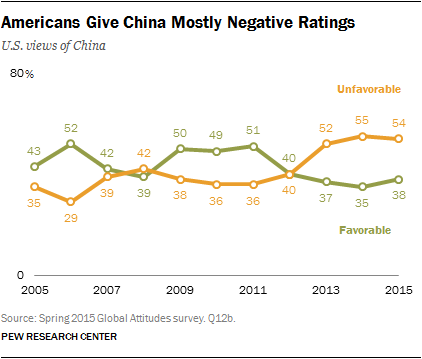

In [ ]:
train_dataset[0]['images'][0]

Vamos a hacer una función a la que le pasemos una pregunta con imagen y nos genere la respuesta del modelo.

In [ ]:
from qwen_vl_utils import process_vision_info
import copy

def generate_text_from_sample(model, processor, sample, max_new_tokens=1024, device="cuda"):
    # Nos quedamos solo con el mensaje del usuario (sin system prompt) para evaluar en zero-shot
    messages = copy.deepcopy(sample['messages'][1:2])

    # process_vision_info necesita la imagen real dentro del mensaje,
    # así que sustituimos el placeholder {"type": "image"} por la imagen real
    image_iter = iter(sample['images'])
    for msg in messages:
        for content in msg['content']:
            if content.get('type') == 'image':
                content['image'] = next(image_iter)

    # Preparamos el texto aplicando la plantilla de chat del modelo
    text_input = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    # Ahora sí extraemos las imágenes, ya embebidas en los mensajes
    image_inputs, _ = process_vision_info(messages)

    # Preparamos las entradas para el modelo
    model_inputs = processor(text=[text_input], images=image_inputs, return_tensors="pt").to(device)

    # Generamos texto con el modelo
    generated_ids = model.generate(**model_inputs, max_new_tokens=max_new_tokens)

    # Recortamos los ids generados para quedarnos solo con la parte nueva
    trimmed_generated_ids = [out_ids[len(in_ids):] for in_ids, out_ids in zip(model_inputs.input_ids, generated_ids)]

    # Decodificamos el texto de salida
    output_text = processor.batch_decode(trimmed_generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)

    return output_text[0]

¡Y lo probamos!

In [ ]:
train_dataset[0]

{'messages': [{'role': 'system',
   'content': [{'type': 'text',
     'text': 'You are a Vision Language Model specialized in interpreting visual data from chart images.\nYour task is to analyze the provided chart image and respond to queries with concise answers, usually a single word, number, or short phrase.\nThe charts include a variety of types (e.g., line charts, bar charts) and contain colors, labels, and text.\nFocus on delivering accurate, succinct answers based on the visual information. Avoid additional explanation unless absolutely necessary.'}]},
  {'role': 'user',
   'content': [{'type': 'image'},
    {'type': 'text', 'text': 'Is the value of Favorable 38 in 2015?'}]},
  {'role': 'assistant', 'content': [{'type': 'text', 'text': 'Yes'}]}],
 'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGB size=422x359>]}

In [ ]:
output = generate_text_from_sample(model, processor, train_dataset[0])
output

'Yes, the value of Favorable is 38 in 2015.'

En este caso ha respondido bien.

In [ ]:
train_dataset[1]

{'messages': [{'role': 'system',
   'content': [{'type': 'text',
     'text': 'You are a Vision Language Model specialized in interpreting visual data from chart images.\nYour task is to analyze the provided chart image and respond to queries with concise answers, usually a single word, number, or short phrase.\nThe charts include a variety of types (e.g., line charts, bar charts) and contain colors, labels, and text.\nFocus on delivering accurate, succinct answers based on the visual information. Avoid additional explanation unless absolutely necessary.'}]},
  {'role': 'user',
   'content': [{'type': 'image'},
    {'type': 'text',
     'text': 'How many values are below 40 in Unfavorable graph?'}]},
  {'role': 'assistant', 'content': [{'type': 'text', 'text': '6'}]}],
 'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGB size=422x359>]}

In [ ]:
output = generate_text_from_sample(model, processor, train_dataset[1])
output

'There are 4 values below 40 in the Unfavorable graph:\n\n1. 35\n2. 39\n3. 40\n4. 40'

En este otro ha respondido mal, y además ha dicho más cosas de las que le hemos preguntado.

Antes de seguir, vamos a limpiar la GPU para que esté vacía y nos sea más sencillo trabajar con el fine-tuning.

In [ ]:
import gc
import time

def clear_memory():
    # Borramos las variables si existen en el scope global actual
    if 'inputs' in globals(): del globals()['inputs']
    if 'model' in globals(): del globals()['model']
    if 'processor' in globals(): del globals()['processor']
    if 'trainer' in globals(): del globals()['trainer']
    time.sleep(2)

    # Garbage collection y liberamos la memoria CUDA
    gc.collect()
    time.sleep(2)
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    time.sleep(2)
    gc.collect()
    time.sleep(2)

    print(f"GPU allocated memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
    print(f"GPU reserved memory: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

clear_memory()

GPU allocated memory: 4.12 GB
GPU reserved memory: 4.17 GB


## 4. Fine-Tune

Como el modelo de 2B ya cabe en una GPU de este tamaño, para esta clase vamos a saltarnos la cuantización y cargar directamente el modelo en bfloat16, tal y como hicimos para la prueba zero-shot.

In [ ]:
model = Qwen2VLForConditionalGeneration.from_pretrained(model_id,
                                                        device_map="auto",
                                                        torch_dtype=torch.bfloat16)

processor = Qwen2VLProcessor.from_pretrained(model_id)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Y vamos a hacer el fine-tuning usando [LoRA](https://arxiv.org/abs/2106.09685): en vez de entrenar todos los pesos del modelo, entrenamos solo unas pocas matrices adicionales de bajo rango, lo que hace el proceso mucho más ligero en memoria.

In [ ]:
from peft import LoraConfig

# Configuramos LoRA
peft_config = LoraConfig(lora_alpha=32,
                         lora_dropout=0.05,
                         r=16,
                         bias="none",
                         target_modules=["q_proj", "v_proj"],
                         task_type="CAUSAL_LM")

Y ahora ya vamos a usar Supervised Fine-Tuning (SFT) para no tener que escribir el bucle de entrenamiento a mano.

In [ ]:
from trl import SFTConfig

# Configuramos los argumentos de entrenamiento
training_args = SFTConfig(output_dir="qwen2-2b-instruct-trl-sft-ChartQA",  # Carpeta donde se guarda el modelo
                          num_train_epochs=1,  # Número de épocas de entrenamiento
                          per_device_train_batch_size=2,  # Tamaño de batch de entrenamiento
                          per_device_eval_batch_size=2,  # Tamaño de batch de evaluación
                          gradient_accumulation_steps=8,  # Pasos para acumular gradiente
                          gradient_checkpointing_kwargs={"use_reentrant": False},  # Opciones de gradient checkpointing
                          max_length=1024,  # Longitud máxima de secuencia
                          # Optimizador y scheduler
                          optim="adamw_torch_fused",  # Tipo de optimizador
                          learning_rate=2e-4,  # Learning rate
                          # Logging y evaluación
                          logging_steps=5,  # Cada cuántos pasos se loguea
                          eval_steps=10,  # Cada cuántos pasos se evalúa
                          eval_strategy="steps",  # Estrategia de evaluación
                          save_strategy="steps",  # Estrategia de guardado
                          save_steps=20,  # Cada cuántos pasos se guarda
                          # Precisión mixta y gradientes
                          bf16=True,  # Usamos precisión bfloat16
                          max_grad_norm=0.3,  # Norma máxima para el clipping de gradiente
                          warmup_steps=10,  # Pasos de warmup
                          # Hub
                          push_to_hub=False,  # No subimos el modelo al Hub
                          # Muy importante: si no ponemos esto a False, el Trainer elimina
                          # las columnas que no reconoce (como "images"), y el entrenamiento
                          # falla porque el modelo se queda sin las imágenes.
                          remove_unused_columns=False)

Le pasamos todos los argumentos al trainer y los datasets.

Como ya los formateamos correctamente en la sección 2 con `.map()`, podemos pasárselos al `SFTTrainer` directamente.

In [ ]:
from trl import SFTTrainer

trainer = SFTTrainer(model=model,
                     args=training_args,
                     train_dataset=train_dataset,
                     eval_dataset=eval_dataset,
                     peft_config=peft_config,
                     processing_class=processor)

¡Y le damos!

In [ ]:
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss


KeyboardInterrupt: 

Podemos guardar el modelo fácilmente:

In [ ]:
trainer.save_model(training_args.output_dir)

## 5. Testing

Vamos a ver si ha mejorado algo.

Primero vaciamos la memoria...

In [ ]:
clear_memory()

Volvemos a cargar el modelo base.

In [ ]:
model = Qwen2VLForConditionalGeneration.from_pretrained(model_id,
                                                        device_map="auto",
                                                        torch_dtype=torch.bfloat16)

processor = Qwen2VLProcessor.from_pretrained(model_id)

Y le cargamos el adaptador LoRA que acabamos de entrenar.

In [ ]:
adapter_path = training_args.output_dir
model.load_adapter(adapter_path)

Probamos de nuevo con la misma pregunta que fallaba antes del fine-tuning, para comparar:

In [ ]:
output = generate_text_from_sample(model, processor, train_dataset[1])
output